# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [11]:
pip install pandas numpy matplotlib yfinance


Note: you may need to restart the kernel to use updated packages.


In [12]:
!python.exe -m pip install --upgrade pip

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Download market data
ticker = "SPY"
data = yf.download(ticker, start="2018-01-01", end="2025-01-01")

# Show first few rows
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2018-01-02,236.562164,236.597378,235.356341,235.743617,86655700
2018-01-03,238.058456,238.208096,236.729397,236.729397,90070400
2018-01-04,239.061783,239.545890,238.120026,238.700939,80636400
2018-01-05,240.654999,240.778208,239.361154,239.854044,83524000
2018-01-08,241.095078,241.253501,240.267719,240.558162,57319200


In [14]:
# Keep only closing price
data = data[["Close"]].copy()
data.dropna(inplace=True)

# Calculate daily returns
data["Daily_Return"] = data["Close"].pct_change()

data.head()

Price,Close,Daily_Return
Ticker,SPY,
Date,,
2018-01-02,236.562164,NaN
2018-01-03,238.058456,0.006325
2018-01-04,239.061783,0.004215
2018-01-05,240.654999,0.006664
2018-01-08,241.095078,0.001829


In [15]:
# Calculate moving averages
data["MA20"] = data["Close"].rolling(window=20).mean()
data["MA50"] = data["Close"].rolling(window=50).mean()

data.tail()

Price,Close,Daily_Return,MA20,MA50
Ticker,SPY,,,
Date,,,,
2024-12-24,592.702148,0.011115,590.998615,581.681537
2024-12-26,592.741577,0.000067,591.131924,582.144911
2024-12-27,586.502075,-0.010527,591.042654,582.433982
2024-12-30,579.809143,-0.011412,590.436011,582.588214
2024-12-31,577.699707,-0.003638,589.670850,582.656245


In [16]:
# Create signal
data["Signal"] = 0
data.loc[data["MA20"] > data["MA50"], "Signal"] = 1
data.loc[data["MA20"] <= data["MA50"], "Signal"] = 0

# Avoid look-ahead bias
data["Position"] = data["Signal"].shift(1)

data.tail()

Price,Close,Daily_Return,MA20,MA50,Signal,Position
Ticker,SPY,,,,,
Date,,,,,,
2024-12-24,592.702148,0.011115,590.998615,581.681537,1,1.0
2024-12-26,592.741577,0.000067,591.131924,582.144911,1,1.0
2024-12-27,586.502075,-0.010527,591.042654,582.433982,1,1.0
2024-12-30,579.809143,-0.011412,590.436011,582.588214,1,1.0
2024-12-31,577.699707,-0.003638,589.670850,582.656245,1,1.0


In [17]:
# Calculate strategy returns
data["Strategy_Return"] = data["Position"] * data["Daily_Return"]
data.dropna(inplace=True)

data.tail()

Price,Close,Daily_Return,MA20,MA50,Signal,Position,Strategy_Return
Ticker,SPY,,,,,,
Date,,,,,,,
2024-12-24,592.702148,0.011115,590.998615,581.681537,1,1.0,0.011115
2024-12-26,592.741577,0.000067,591.131924,582.144911,1,1.0,0.000067
2024-12-27,586.502075,-0.010527,591.042654,582.433982,1,1.0,-0.010527
2024-12-30,579.809143,-0.011412,590.436011,582.588214,1,1.0,-0.011412
2024-12-31,577.699707,-0.003638,589.670850,582.656245,1,1.0,-0.003638


In [18]:
# Calculate growth
data["Buy_Hold_Growth"] = (1 + data["Daily_Return"]).cumprod()
data["Strategy_Growth"] = (1 + data["Strategy_Return"]).cumprod()

data.tail()

Price,Close,Daily_Return,MA20,MA50,Signal,Position,Strategy_Return,Buy_Hold_Growth,Strategy_Growth
Ticker,SPY,,,,,,,,
Date,,,,,,,,,
2024-12-24,592.702148,0.011115,590.998615,581.681537,1,1.0,0.011115,2.433501,1.624181
2024-12-26,592.741577,0.000067,591.131924,582.144911,1,1.0,0.000067,2.433663,1.624289
2024-12-27,586.502075,-0.010527,591.042654,582.433982,1,1.0,-0.010527,2.408045,1.607191
2024-12-30,579.809143,-0.011412,590.436011,582.588214,1,1.0,-0.011412,2.380565,1.588850
2024-12-31,577.699707,-0.003638,589.670850,582.656245,1,1.0,-0.003638,2.371904,1.583070


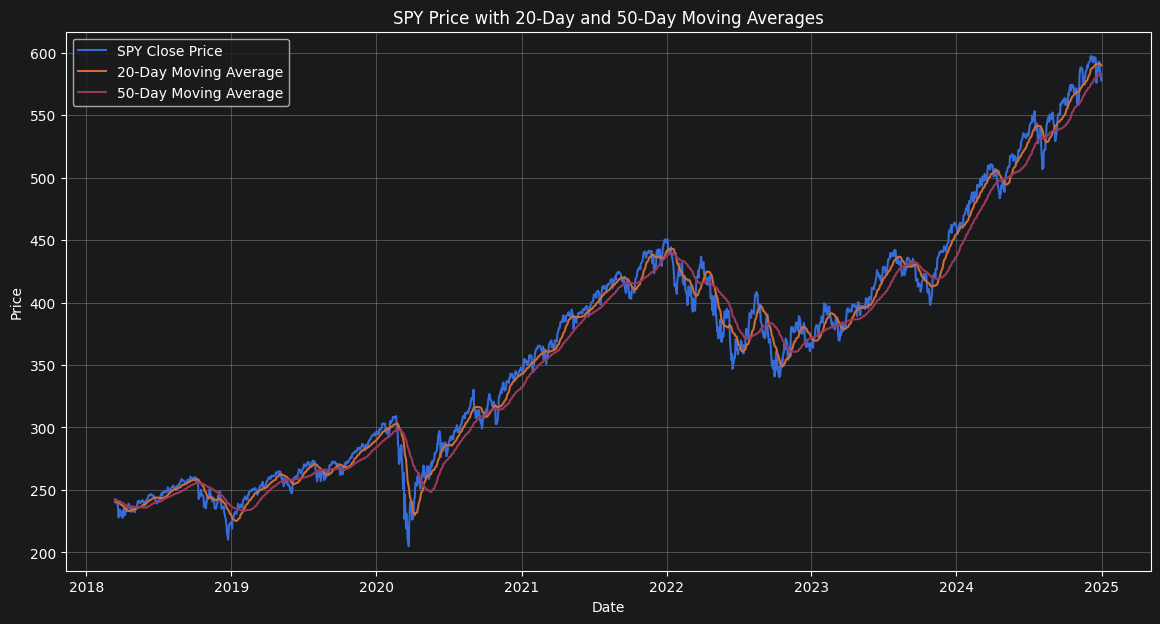

In [19]:
# Plot price and moving averages
plt.figure(figsize=(14, 7))
plt.plot(data["Close"], label="SPY Close Price")
plt.plot(data["MA20"], label="20-Day Moving Average")
plt.plot(data["MA50"], label="50-Day Moving Average")
plt.title("SPY Price with 20-Day and 50-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

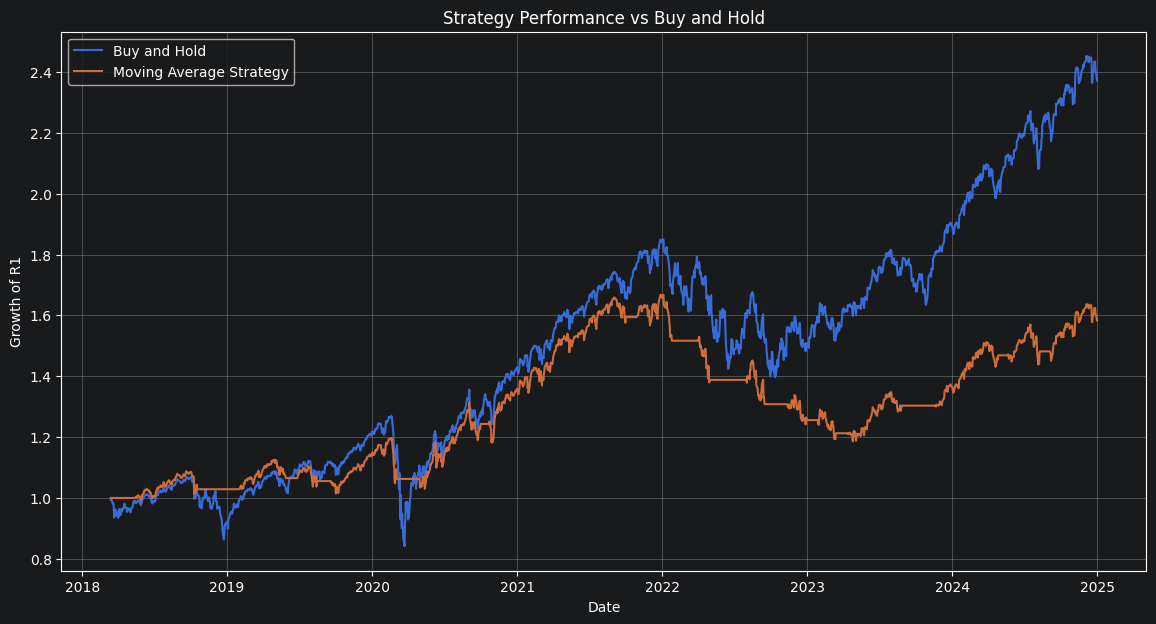

In [20]:
# Plot strategy performance
plt.figure(figsize=(14, 7))
plt.plot(data["Buy_Hold_Growth"], label="Buy and Hold")
plt.plot(data["Strategy_Growth"], label="Moving Average Strategy")
plt.title("Strategy Performance vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Growth of R1")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Performance metrics
buy_hold_return = data["Buy_Hold_Growth"].iloc[-1] - 1
strategy_return = data["Strategy_Growth"].iloc[-1] - 1

buy_hold_volatility = data["Daily_Return"].std() * np.sqrt(252)
strategy_volatility = data["Strategy_Return"].std() * np.sqrt(252)

buy_hold_sharpe = (data["Daily_Return"].mean() * 252) / buy_hold_volatility
strategy_sharpe = (data["Strategy_Return"].mean() * 252) / strategy_volatility

print("Buy and Hold Return:", round(buy_hold_return * 100, 2), "%")
print("Strategy Return:", round(strategy_return * 100, 2), "%")

print("Buy and Hold Volatility:", round(buy_hold_volatility * 100, 2), "%")
print("Strategy Volatility:", round(strategy_volatility * 100, 2), "%")

print("Buy and Hold Sharpe Ratio:", round(buy_hold_sharpe, 2))
print("Strategy Sharpe Ratio:", round(strategy_sharpe, 2))

Buy and Hold Return: 137.19 %
Strategy Return: 58.31 %
Buy and Hold Volatility: 19.47 %
Strategy Volatility: 12.32 %
Buy and Hold Sharpe Ratio: 0.75
Strategy Sharpe Ratio: 0.61


In [22]:
# Count trades
data["Trade"] = data["Signal"].diff()

number_of_buy_trades = (data["Trade"] == 1).sum()
number_of_sell_trades = (data["Trade"] == -1).sum()

print("Number of Buy Trades:", number_of_buy_trades)
print("Number of Sell Trades:", number_of_sell_trades)

Number of Buy Trades: 15
Number of Sell Trades: 14


In [23]:
# Calculate running maximum values
data["Buy_Hold_Peak"] = data["Buy_Hold_Growth"].cummax()
data["Strategy_Peak"] = data["Strategy_Growth"].cummax()

# Calculate drawdowns
data["Buy_Hold_Drawdown"] = (data["Buy_Hold_Growth"] - data["Buy_Hold_Peak"]) / data["Buy_Hold_Peak"]
data["Strategy_Drawdown"] = (data["Strategy_Growth"] - data["Strategy_Peak"]) / data["Strategy_Peak"]

# Calculate maximum drawdown
buy_hold_max_drawdown = data["Buy_Hold_Drawdown"].min()
strategy_max_drawdown = data["Strategy_Drawdown"].min()

print("Buy and Hold Max Drawdown:", round(buy_hold_max_drawdown * 100, 2), "%")
print("Strategy Max Drawdown:", round(strategy_max_drawdown * 100, 2), "%")

Buy and Hold Max Drawdown: -33.72 %
Strategy Max Drawdown: -28.89 %


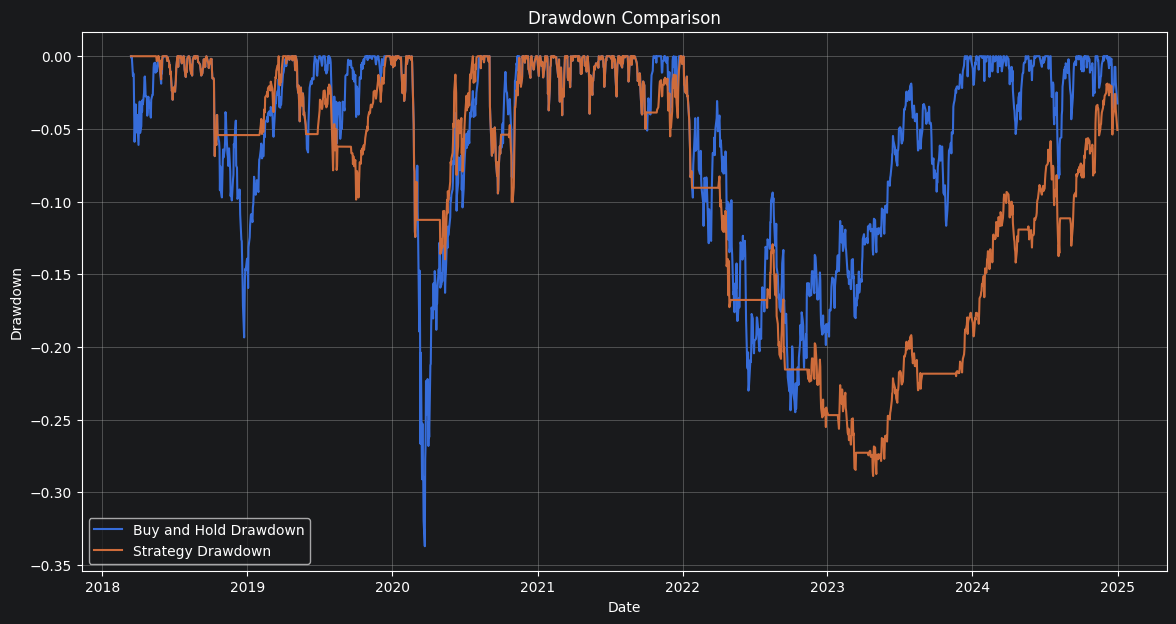

In [25]:
plt.figure(figsize=(14, 7))
plt.plot(data["Buy_Hold_Drawdown"], label="Buy and Hold Drawdown")
plt.plot(data["Strategy_Drawdown"], label="Strategy Drawdown")
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
initial_capital = 10000

data["Buy_Hold_Equity"] = initial_capital * data["Buy_Hold_Growth"]
data["Strategy_Equity"] = initial_capital * data["Strategy_Growth"]

print("Final Buy and Hold Value: R", round(data["Buy_Hold_Equity"].iloc[-1], 2))
print("Final Strategy Value: R", round(data["Strategy_Equity"].iloc[-1], 2))

Final Buy and Hold Value: R 23719.04
Final Strategy Value: R 15830.7


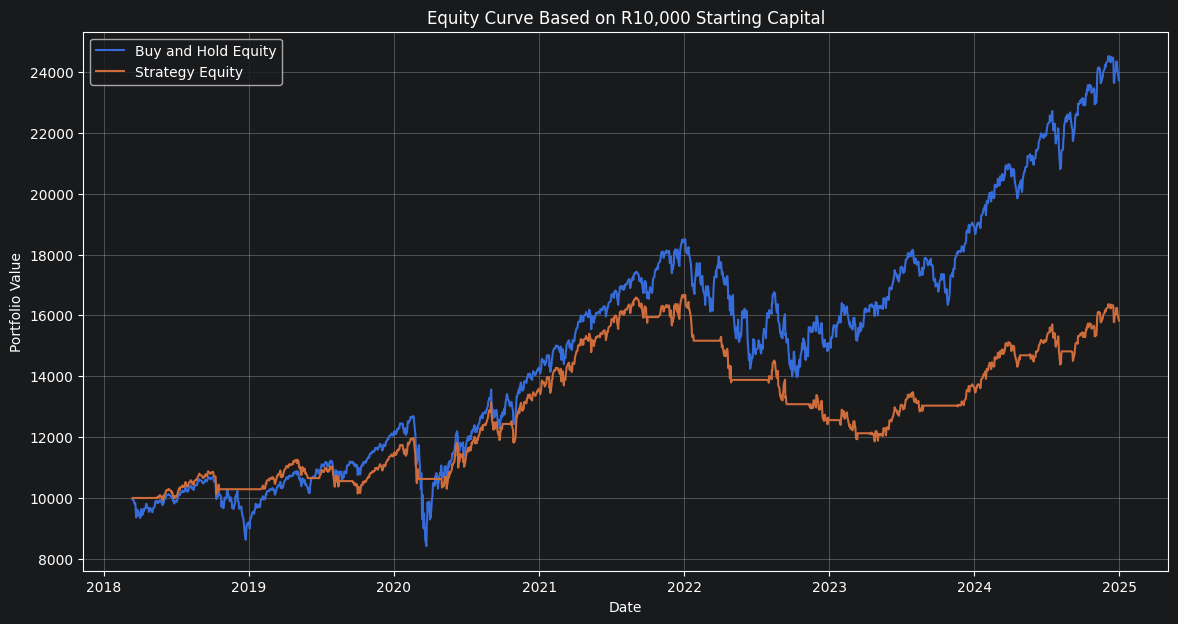

In [27]:
plt.figure(figsize=(14, 7))
plt.plot(data["Buy_Hold_Equity"], label="Buy and Hold Equity")
plt.plot(data["Strategy_Equity"], label="Strategy Equity")
plt.title("Equity Curve Based on R10,000 Starting Capital")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Set trading cost per transaction
trading_cost = 0.001  # 0.10% per trade

# Identify when trades happen
data["Trade_Event"] = data["Position"].diff().abs()

# Replace NaN with 0
data["Trade_Event"] = data["Trade_Event"].fillna(0)

# Calculate cost-adjusted strategy return
data["Strategy_Return_After_Cost"] = data["Strategy_Return"] - (data["Trade_Event"] * trading_cost)

# Calculate cost-adjusted growth
data["Strategy_Growth_After_Cost"] = (1 + data["Strategy_Return_After_Cost"]).cumprod()

data[["Strategy_Return", "Trade_Event", "Strategy_Return_After_Cost", "Strategy_Growth_After_Cost"]].tail()

Price,Strategy_Return,Trade_Event,Strategy_Return_After_Cost,Strategy_Growth_After_Cost
Ticker,,,,
Date,,,,
2024-12-24,0.011115,0.0,0.011115,1.577668
2024-12-26,0.000067,0.0,0.000067,1.577773
2024-12-27,-0.010527,0.0,-0.010527,1.561165
2024-12-30,-0.011412,0.0,-0.011412,1.543350
2024-12-31,-0.003638,0.0,-0.003638,1.537735


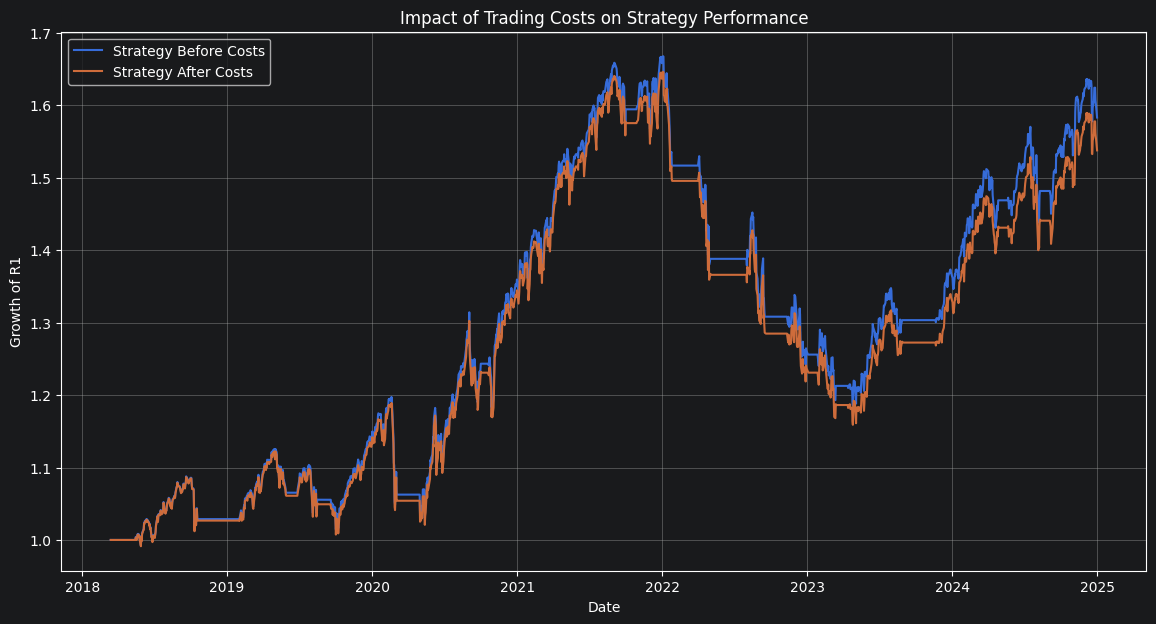

In [29]:
plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Growth"], label="Strategy Before Costs")
plt.plot(data["Strategy_Growth_After_Cost"], label="Strategy After Costs")
plt.title("Impact of Trading Costs on Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Growth of R1")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Calculate cost-adjusted total return
strategy_return_after_cost = data["Strategy_Growth_After_Cost"].iloc[-1] - 1

# Calculate cost-adjusted volatility
strategy_volatility_after_cost = data["Strategy_Return_After_Cost"].std() * np.sqrt(252)

# Calculate cost-adjusted Sharpe ratio
strategy_sharpe_after_cost = (
    data["Strategy_Return_After_Cost"].mean() * 252
) / strategy_volatility_after_cost

print("Strategy Return Before Costs:", round(strategy_return * 100, 2), "%")
print("Strategy Return After Costs:", round(strategy_return_after_cost * 100, 2), "%")

print("Strategy Volatility Before Costs:", round(strategy_volatility * 100, 2), "%")
print("Strategy Volatility After Costs:", round(strategy_volatility_after_cost * 100, 2), "%")

print("Strategy Sharpe Ratio Before Costs:", round(strategy_sharpe, 2))
print("Strategy Sharpe Ratio After Costs:", round(strategy_sharpe_after_cost, 2))

Strategy Return Before Costs: 58.31 %
Strategy Return After Costs: 53.77 %
Strategy Volatility Before Costs: 12.32 %
Strategy Volatility After Costs: 12.32 %
Strategy Sharpe Ratio Before Costs: 0.61
Strategy Sharpe Ratio After Costs: 0.58


In [31]:
# Calculate peak and drawdown after costs
data["Strategy_Peak_After_Cost"] = data["Strategy_Growth_After_Cost"].cummax()
data["Strategy_Drawdown_After_Cost"] = (
    data["Strategy_Growth_After_Cost"] - data["Strategy_Peak_After_Cost"]
) / data["Strategy_Peak_After_Cost"]

strategy_max_drawdown_after_cost = data["Strategy_Drawdown_After_Cost"].min()

print("Strategy Max Drawdown Before Costs:", round(strategy_max_drawdown * 100, 2), "%")
print("Strategy Max Drawdown After Costs:", round(strategy_max_drawdown_after_cost * 100, 2), "%")

Strategy Max Drawdown Before Costs: -28.89 %
Strategy Max Drawdown After Costs: -29.6 %


Final Strategy Value Before Costs: R 15830.7
Final Strategy Value After Costs: R 15377.35


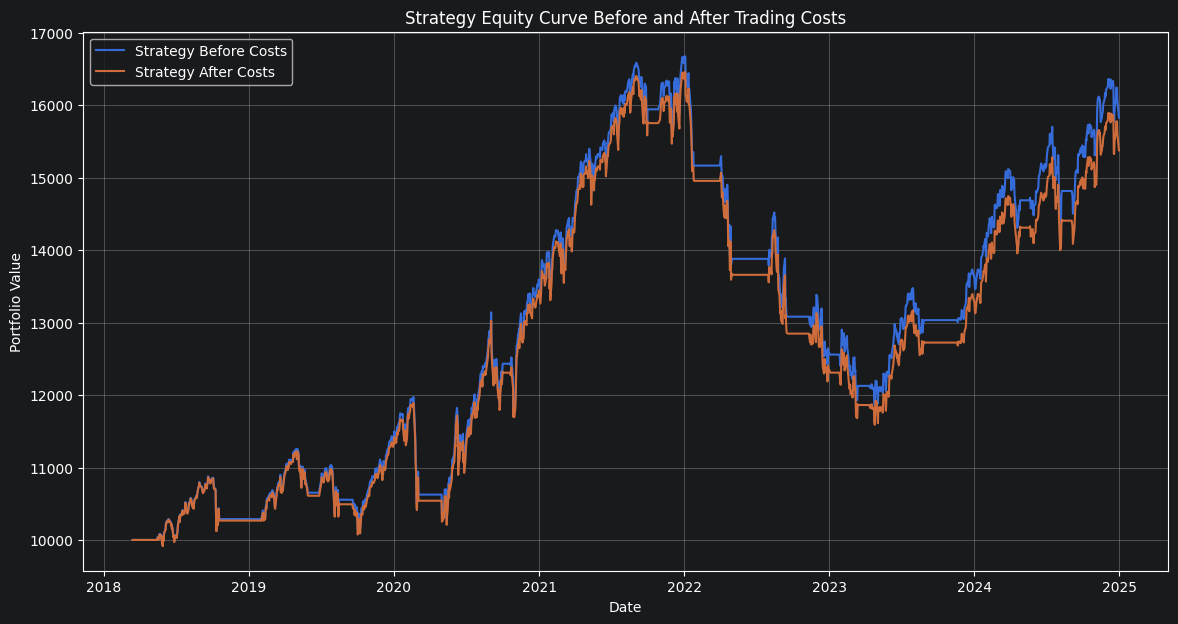

In [32]:
data["Strategy_Equity_After_Cost"] = initial_capital * data["Strategy_Growth_After_Cost"]

print("Final Strategy Value Before Costs: R", round(data["Strategy_Equity"].iloc[-1], 2))
print("Final Strategy Value After Costs: R", round(data["Strategy_Equity_After_Cost"].iloc[-1], 2))

plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Equity"], label="Strategy Before Costs")
plt.plot(data["Strategy_Equity_After_Cost"], label="Strategy After Costs")
plt.title("Strategy Equity Curve Before and After Trading Costs")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# Position sizing
position_size = 0.50  # Use 50% of capital when in a trade

# Adjust strategy return based on position size
data["Strategy_Return_Position_Sized"] = data["Strategy_Return_After_Cost"] * position_size

# Calculate growth
data["Strategy_Growth_Position_Sized"] = (1 + data["Strategy_Return_Position_Sized"]).cumprod()

data[[
    "Strategy_Return_After_Cost",
    "Strategy_Return_Position_Sized",
    "Strategy_Growth_Position_Sized"
]].tail()

Price,Strategy_Return_After_Cost,Strategy_Return_Position_Sized,Strategy_Growth_Position_Sized
Ticker,,,
Date,,,
2024-12-24,0.011115,0.005558,1.272435
2024-12-26,0.000067,0.000033,1.272477
2024-12-27,-0.010527,-0.005263,1.265780
2024-12-30,-0.011412,-0.005706,1.258557
2024-12-31,-0.003638,-0.001819,1.256268


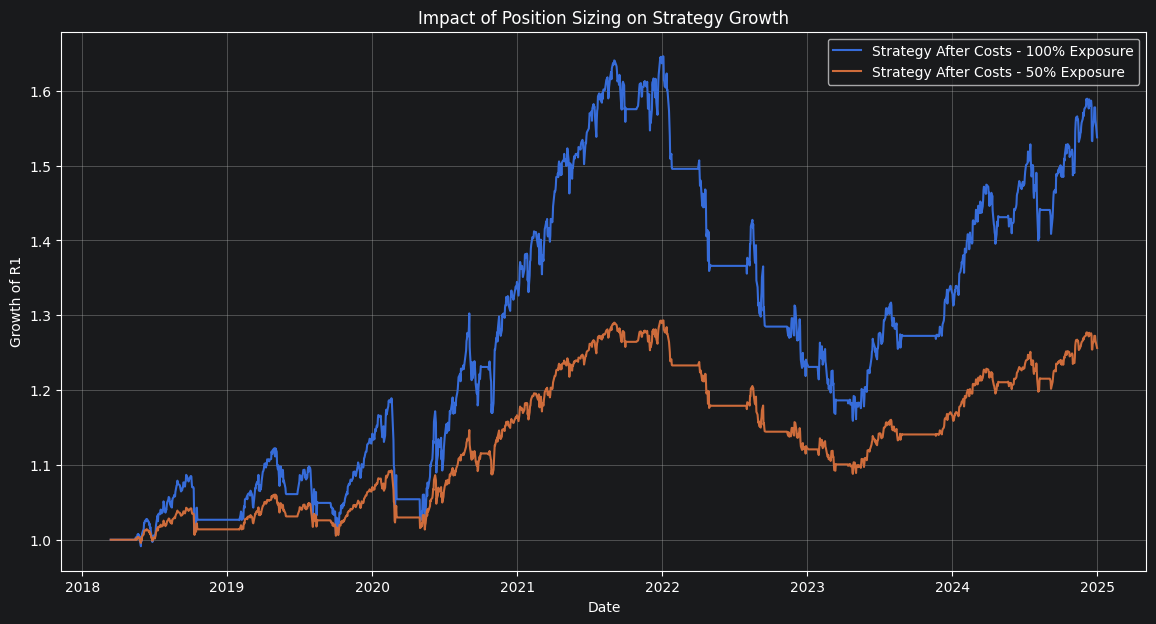

In [34]:
plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Growth_After_Cost"], label="Strategy After Costs - 100% Exposure")
plt.plot(data["Strategy_Growth_Position_Sized"], label="Strategy After Costs - 50% Exposure")
plt.title("Impact of Position Sizing on Strategy Growth")
plt.xlabel("Date")
plt.ylabel("Growth of R1")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# Total return
strategy_return_position_sized = data["Strategy_Growth_Position_Sized"].iloc[-1] - 1

# Volatility
strategy_volatility_position_sized = data["Strategy_Return_Position_Sized"].std() * np.sqrt(252)

# Sharpe ratio
strategy_sharpe_position_sized = (
    data["Strategy_Return_Position_Sized"].mean() * 252
) / strategy_volatility_position_sized

print("Strategy Return After Costs - 100% Exposure:", round(strategy_return_after_cost * 100, 2), "%")
print("Strategy Return After Costs - 50% Exposure:", round(strategy_return_position_sized * 100, 2), "%")

print("Strategy Volatility After Costs - 100% Exposure:", round(strategy_volatility_after_cost * 100, 2), "%")
print("Strategy Volatility After Costs - 50% Exposure:", round(strategy_volatility_position_sized * 100, 2), "%")

print("Strategy Sharpe After Costs - 100% Exposure:", round(strategy_sharpe_after_cost, 2))
print("Strategy Sharpe After Costs - 50% Exposure:", round(strategy_sharpe_position_sized, 2))

Strategy Return After Costs - 100% Exposure: 53.77 %
Strategy Return After Costs - 50% Exposure: 25.63 %
Strategy Volatility After Costs - 100% Exposure: 12.32 %
Strategy Volatility After Costs - 50% Exposure: 6.16 %
Strategy Sharpe After Costs - 100% Exposure: 0.58
Strategy Sharpe After Costs - 50% Exposure: 0.58


In [36]:
# Calculate peak and drawdown for position-sized strategy
data["Strategy_Peak_Position_Sized"] = data["Strategy_Growth_Position_Sized"].cummax()

data["Strategy_Drawdown_Position_Sized"] = (
    data["Strategy_Growth_Position_Sized"] - data["Strategy_Peak_Position_Sized"]
) / data["Strategy_Peak_Position_Sized"]

strategy_max_drawdown_position_sized = data["Strategy_Drawdown_Position_Sized"].min()

print("Strategy Max Drawdown After Costs - 100% Exposure:", round(strategy_max_drawdown_after_cost * 100, 2), "%")
print("Strategy Max Drawdown After Costs - 50% Exposure:", round(strategy_max_drawdown_position_sized * 100, 2), "%")

Strategy Max Drawdown After Costs - 100% Exposure: -29.6 %
Strategy Max Drawdown After Costs - 50% Exposure: -15.86 %


Final Strategy Value After Costs - 100% Exposure: R 15377.35
Final Strategy Value After Costs - 50% Exposure: R 12562.68


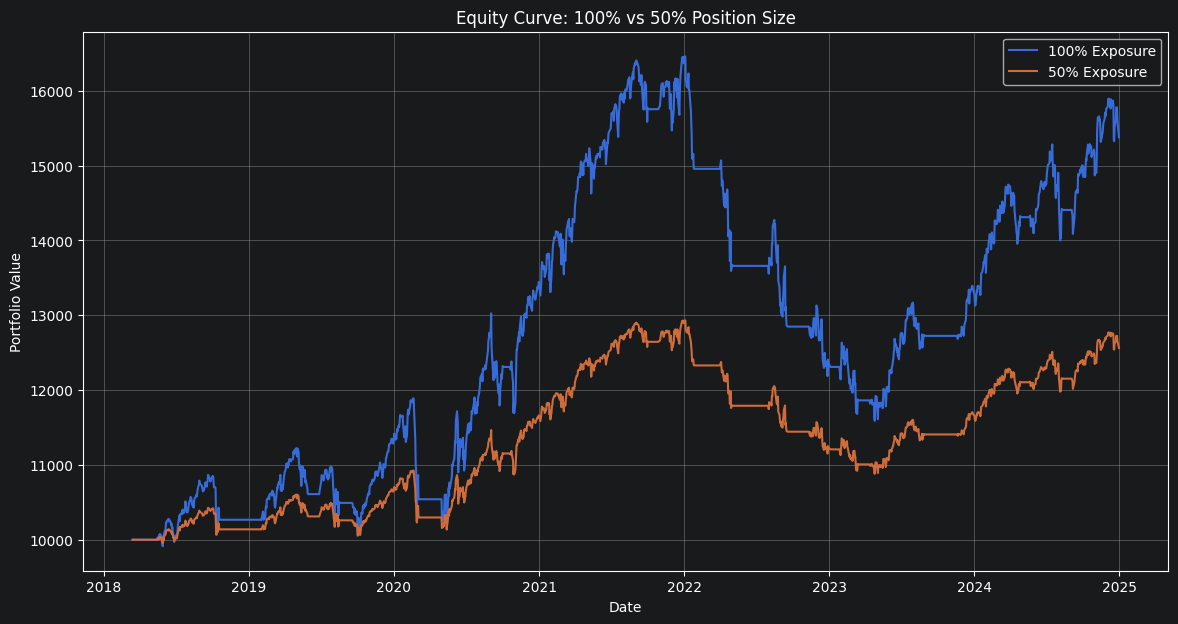

In [37]:
data["Strategy_Equity_Position_Sized"] = initial_capital * data["Strategy_Growth_Position_Sized"]

print("Final Strategy Value After Costs - 100% Exposure: R", round(data["Strategy_Equity_After_Cost"].iloc[-1], 2))
print("Final Strategy Value After Costs - 50% Exposure: R", round(data["Strategy_Equity_Position_Sized"].iloc[-1], 2))

plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Equity_After_Cost"], label="100% Exposure")
plt.plot(data["Strategy_Equity_Position_Sized"], label="50% Exposure")
plt.title("Equity Curve: 100% vs 50% Position Size")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Portfolio-level risk stop
max_allowed_drawdown = -0.10  # Stop trading if drawdown reaches -10%

# Create a new column for risk status
data["Risk_Stop_Triggered"] = data["Strategy_Drawdown_Position_Sized"] <= max_allowed_drawdown

# Once the risk stop is triggered, remain in risk-off mode
data["Risk_Off_Mode"] = data["Risk_Stop_Triggered"].cummax()

# Create risk-managed returns
data["Strategy_Return_Risk_Managed"] = data["Strategy_Return_Position_Sized"]

# If risk-off mode is active, stop trading by setting returns to 0
data.loc[data["Risk_Off_Mode"], "Strategy_Return_Risk_Managed"] = 0

# Calculate growth of the risk-managed strategy
data["Strategy_Growth_Risk_Managed"] = (1 + data["Strategy_Return_Risk_Managed"]).cumprod()

data[[
    "Strategy_Return_Position_Sized",
    "Strategy_Drawdown_Position_Sized",
    "Risk_Stop_Triggered",
    "Risk_Off_Mode",
    "Strategy_Return_Risk_Managed",
    "Strategy_Growth_Risk_Managed"
]].tail()

Price,Strategy_Return_Position_Sized,Strategy_Drawdown_Position_Sized,Risk_Stop_Triggered,Risk_Off_Mode,Strategy_Return_Risk_Managed,Strategy_Growth_Risk_Managed
Ticker,,,,,,
Date,,,,,,
2024-12-24,0.005558,-0.016037,False,True,0.0,1.167165
2024-12-26,0.000033,-0.016004,False,True,0.0,1.167165
2024-12-27,-0.005263,-0.021184,False,True,0.0,1.167165
2024-12-30,-0.005706,-0.026768,False,True,0.0,1.167165
2024-12-31,-0.001819,-0.028539,False,True,0.0,1.167165


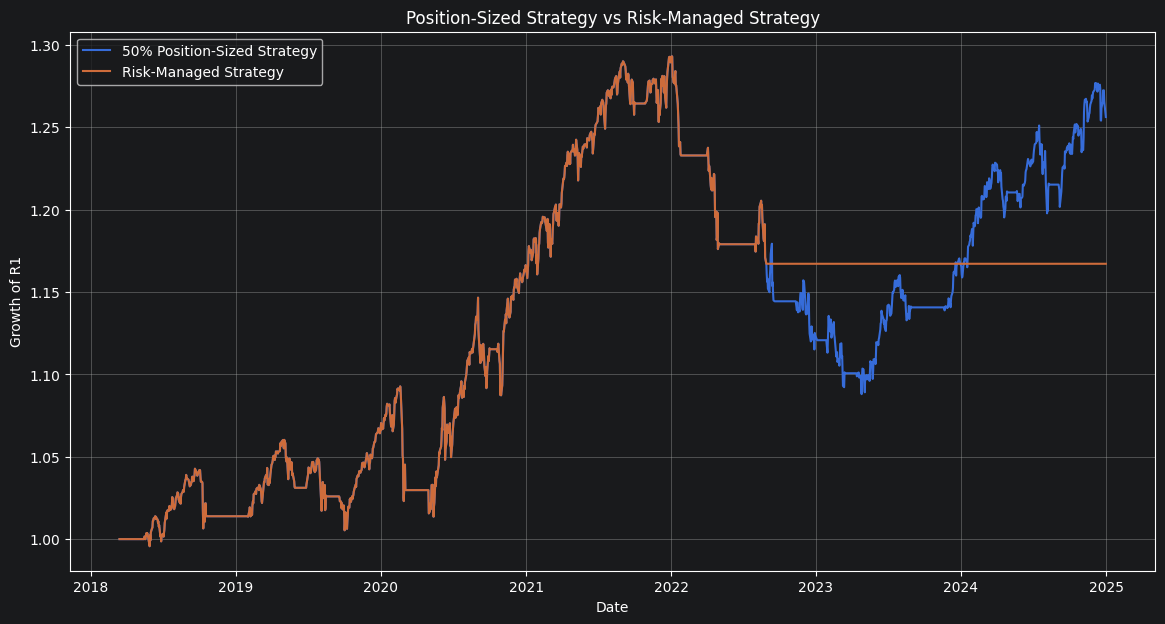

In [39]:
plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Growth_Position_Sized"], label="50% Position-Sized Strategy")
plt.plot(data["Strategy_Growth_Risk_Managed"], label="Risk-Managed Strategy")
plt.title("Position-Sized Strategy vs Risk-Managed Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of R1")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# Total return
strategy_return_risk_managed = data["Strategy_Growth_Risk_Managed"].iloc[-1] - 1

# Volatility
strategy_volatility_risk_managed = data["Strategy_Return_Risk_Managed"].std() * np.sqrt(252)

# Sharpe ratio
strategy_sharpe_risk_managed = (
    data["Strategy_Return_Risk_Managed"].mean() * 252
) / strategy_volatility_risk_managed

print("Strategy Return - 50% Position Sized:", round(strategy_return_position_sized * 100, 2), "%")
print("Strategy Return - Risk Managed:", round(strategy_return_risk_managed * 100, 2), "%")

print("Strategy Volatility - 50% Position Sized:", round(strategy_volatility_position_sized * 100, 2), "%")
print("Strategy Volatility - Risk Managed:", round(strategy_volatility_risk_managed * 100, 2), "%")

print("Strategy Sharpe - 50% Position Sized:", round(strategy_sharpe_position_sized, 2))
print("Strategy Sharpe - Risk Managed:", round(strategy_sharpe_risk_managed, 2))

Strategy Return - 50% Position Sized: 25.63 %
Strategy Return - Risk Managed: 16.72 %
Strategy Volatility - 50% Position Sized: 6.16 %
Strategy Volatility - Risk Managed: 5.17 %
Strategy Sharpe - 50% Position Sized: 0.58
Strategy Sharpe - Risk Managed: 0.47


In [42]:
# Calculate peak and drawdown for risk-managed strategy
data["Strategy_Peak_Risk_Managed"] = data["Strategy_Growth_Risk_Managed"].cummax()

data["Strategy_Drawdown_Risk_Managed"] = (
    data["Strategy_Growth_Risk_Managed"] - data["Strategy_Peak_Risk_Managed"]
) / data["Strategy_Peak_Risk_Managed"]

strategy_max_drawdown_risk_managed = data["Strategy_Drawdown_Risk_Managed"].min()

print("Max Drawdown - 50% Position Sized:", round(strategy_max_drawdown_position_sized * 100, 2), "%")
print("Max Drawdown - Risk Managed:", round(strategy_max_drawdown_risk_managed * 100, 2), "%")

Max Drawdown - 50% Position Sized: -15.86 %
Max Drawdown - Risk Managed: -9.74 %


Final Value - 50% Position Sized: R 12562.68
Final Value - Risk Managed: R 11671.65


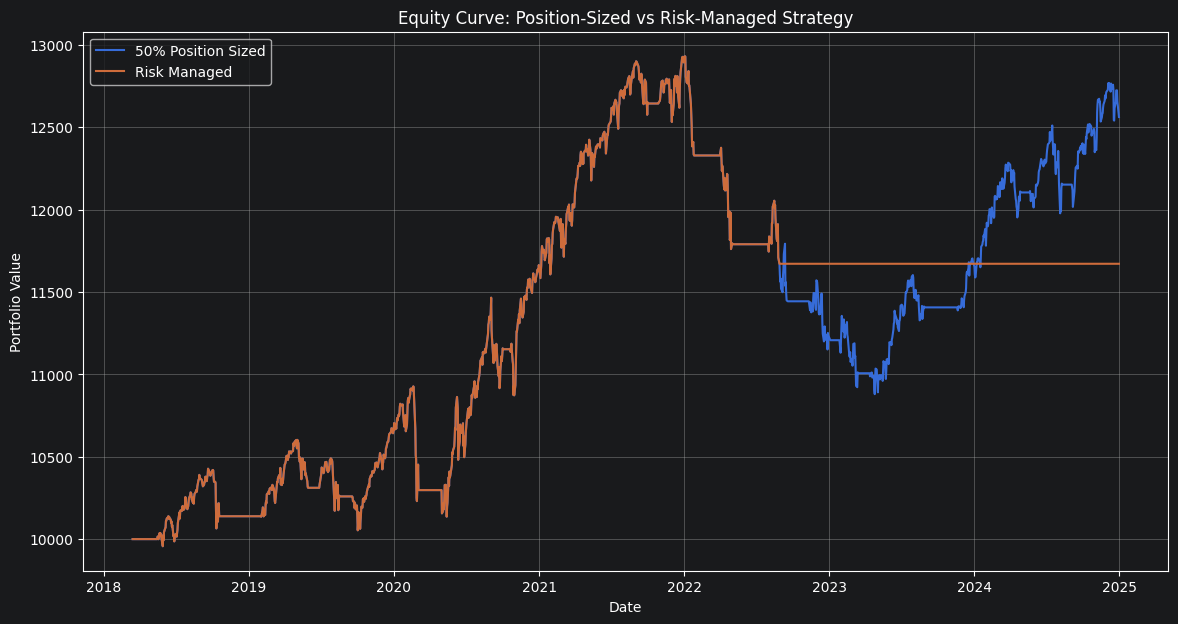

In [43]:
data["Strategy_Equity_Risk_Managed"] = initial_capital * data["Strategy_Growth_Risk_Managed"]

print("Final Value - 50% Position Sized: R", round(data["Strategy_Equity_Position_Sized"].iloc[-1], 2))
print("Final Value - Risk Managed: R", round(data["Strategy_Equity_Risk_Managed"].iloc[-1], 2))

plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Equity_Position_Sized"], label="50% Position Sized")
plt.plot(data["Strategy_Equity_Risk_Managed"], label="Risk Managed")
plt.title("Equity Curve: Position-Sized vs Risk-Managed Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
# Better risk-off rule with re-entry

max_allowed_drawdown = -0.10   # Pause trading if drawdown reaches -10%
cooldown_days = 20             # Stay out of the market for 20 trading days

# Create empty list to store risk-managed returns
risk_managed_returns_reentry = []

# Track cooldown status
cooldown_counter = 0

# Loop through each row of data
for i in range(len(data)):

    current_drawdown = data["Strategy_Drawdown_Position_Sized"].iloc[i]
    current_return = data["Strategy_Return_Position_Sized"].iloc[i]

    # If currently in cooldown, do not trade
    if cooldown_counter > 0:
        risk_managed_returns_reentry.append(0)
        cooldown_counter -= 1

    # If drawdown breaches limit, enter cooldown
    elif current_drawdown <= max_allowed_drawdown:
        risk_managed_returns_reentry.append(0)
        cooldown_counter = cooldown_days

    # Otherwise, trade normally
    else:
        risk_managed_returns_reentry.append(current_return)

# Add results to dataframe
data["Strategy_Return_Risk_Managed_Reentry"] = risk_managed_returns_reentry

# Calculate growth
data["Strategy_Growth_Risk_Managed_Reentry"] = (
    1 + data["Strategy_Return_Risk_Managed_Reentry"]
).cumprod()

data[[
    "Strategy_Return_Position_Sized",
    "Strategy_Drawdown_Position_Sized",
    "Strategy_Return_Risk_Managed_Reentry",
    "Strategy_Growth_Risk_Managed_Reentry"
]].tail()

Price,Strategy_Return_Position_Sized,Strategy_Drawdown_Position_Sized,Strategy_Return_Risk_Managed_Reentry,Strategy_Growth_Risk_Managed_Reentry
Ticker,,,,
Date,,,,
2024-12-24,0.005558,-0.016037,0.005558,1.248887
2024-12-26,0.000033,-0.016004,0.000033,1.248928
2024-12-27,-0.005263,-0.021184,-0.005263,1.242355
2024-12-30,-0.005706,-0.026768,-0.005706,1.235266
2024-12-31,-0.001819,-0.028539,-0.001819,1.233019


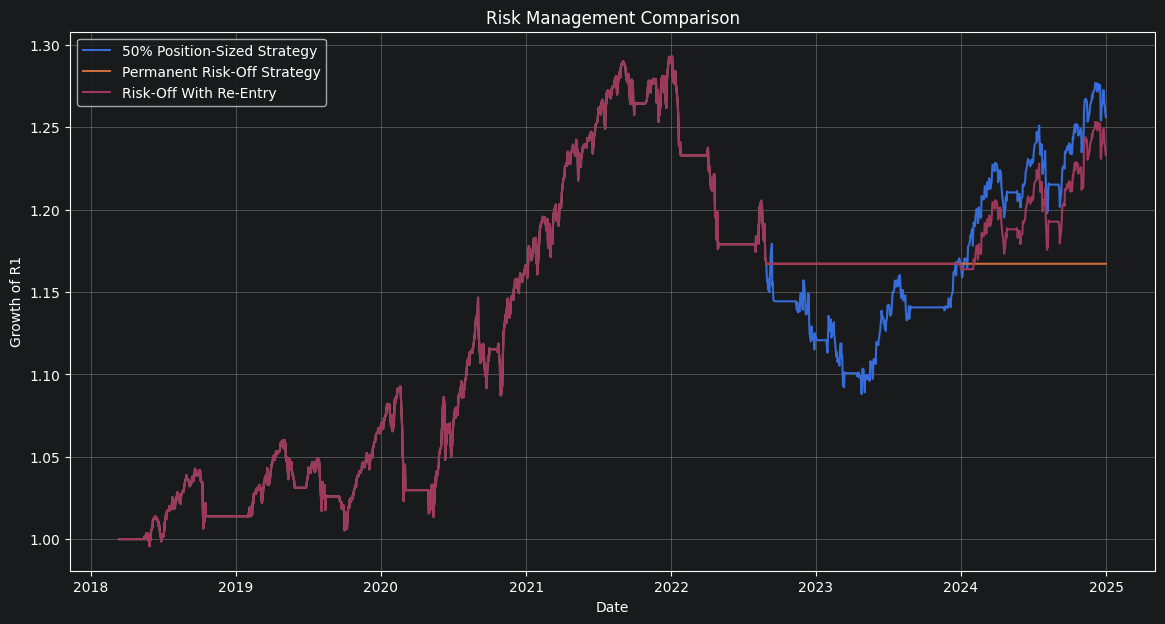

In [45]:
plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Growth_Position_Sized"], label="50% Position-Sized Strategy")
plt.plot(data["Strategy_Growth_Risk_Managed"], label="Permanent Risk-Off Strategy")
plt.plot(data["Strategy_Growth_Risk_Managed_Reentry"], label="Risk-Off With Re-Entry")
plt.title("Risk Management Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of R1")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# Total return
strategy_return_reentry = data["Strategy_Growth_Risk_Managed_Reentry"].iloc[-1] - 1

# Volatility
strategy_volatility_reentry = (
    data["Strategy_Return_Risk_Managed_Reentry"].std() * np.sqrt(252)
)

# Sharpe ratio
strategy_sharpe_reentry = (
    data["Strategy_Return_Risk_Managed_Reentry"].mean() * 252
) / strategy_volatility_reentry

print("Return - 50% Position Sized:", round(strategy_return_position_sized * 100, 2), "%")
print("Return - Permanent Risk-Off:", round(strategy_return_risk_managed * 100, 2), "%")
print("Return - Risk-Off With Re-Entry:", round(strategy_return_reentry * 100, 2), "%")

print("Volatility - 50% Position Sized:", round(strategy_volatility_position_sized * 100, 2), "%")
print("Volatility - Permanent Risk-Off:", round(strategy_volatility_risk_managed * 100, 2), "%")
print("Volatility - Risk-Off With Re-Entry:", round(strategy_volatility_reentry * 100, 2), "%")

print("Sharpe - 50% Position Sized:", round(strategy_sharpe_position_sized, 2))
print("Sharpe - Permanent Risk-Off:", round(strategy_sharpe_risk_managed, 2))
print("Sharpe - Risk-Off With Re-Entry:", round(strategy_sharpe_reentry, 2))

Return - 50% Position Sized: 25.63 %
Return - Permanent Risk-Off: 16.72 %
Return - Risk-Off With Re-Entry: 23.3 %
Volatility - 50% Position Sized: 6.16 %
Volatility - Permanent Risk-Off: 5.17 %
Volatility - Risk-Off With Re-Entry: 5.6 %
Sharpe - 50% Position Sized: 0.58
Sharpe - Permanent Risk-Off: 0.47
Sharpe - Risk-Off With Re-Entry: 0.58


In [47]:
# Calculate peak and drawdown for re-entry risk-managed strategy
data["Strategy_Peak_Risk_Managed_Reentry"] = (
    data["Strategy_Growth_Risk_Managed_Reentry"].cummax()
)

data["Strategy_Drawdown_Risk_Managed_Reentry"] = (
    data["Strategy_Growth_Risk_Managed_Reentry"] -
    data["Strategy_Peak_Risk_Managed_Reentry"]
) / data["Strategy_Peak_Risk_Managed_Reentry"]

strategy_max_drawdown_reentry = data["Strategy_Drawdown_Risk_Managed_Reentry"].min()

print("Max Drawdown - 50% Position Sized:", round(strategy_max_drawdown_position_sized * 100, 2), "%")
print("Max Drawdown - Permanent Risk-Off:", round(strategy_max_drawdown_risk_managed * 100, 2), "%")
print("Max Drawdown - Risk-Off With Re-Entry:", round(strategy_max_drawdown_reentry * 100, 2), "%")

Max Drawdown - 50% Position Sized: -15.86 %
Max Drawdown - Permanent Risk-Off: -9.74 %
Max Drawdown - Risk-Off With Re-Entry: -10.0 %


Final Value - 50% Position Sized: R 12562.68
Final Value - Permanent Risk-Off: R 11671.65
Final Value - Risk-Off With Re-Entry: R 12330.19


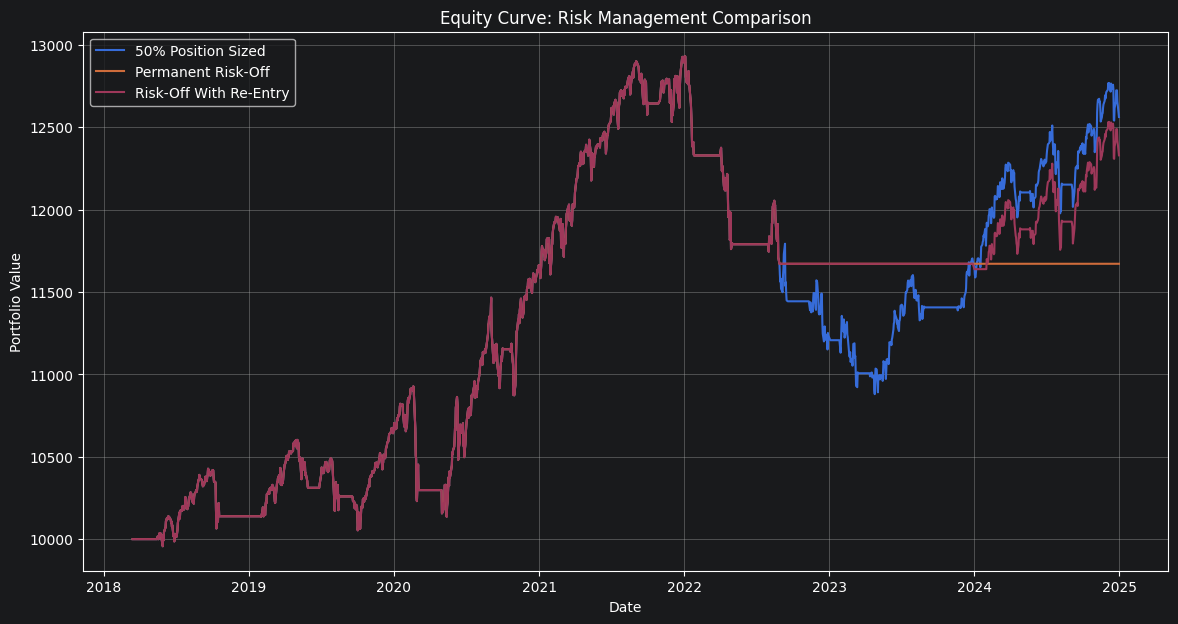

In [48]:
data["Strategy_Equity_Risk_Managed_Reentry"] = (
    initial_capital * data["Strategy_Growth_Risk_Managed_Reentry"]
)

print("Final Value - 50% Position Sized: R", round(data["Strategy_Equity_Position_Sized"].iloc[-1], 2))
print("Final Value - Permanent Risk-Off: R", round(data["Strategy_Equity_Risk_Managed"].iloc[-1], 2))
print("Final Value - Risk-Off With Re-Entry: R", round(data["Strategy_Equity_Risk_Managed_Reentry"].iloc[-1], 2))

plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Equity_Position_Sized"], label="50% Position Sized")
plt.plot(data["Strategy_Equity_Risk_Managed"], label="Permanent Risk-Off")
plt.plot(data["Strategy_Equity_Risk_Managed_Reentry"], label="Risk-Off With Re-Entry")
plt.title("Equity Curve: Risk Management Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# Count risk-off trigger events

risk_pause_events = 0
cooldown_counter = 0

for i in range(len(data)):
    current_drawdown = data["Strategy_Drawdown_Position_Sized"].iloc[i]

    if cooldown_counter > 0:
        cooldown_counter -= 1
    elif current_drawdown <= max_allowed_drawdown:
        risk_pause_events += 1
        cooldown_counter = cooldown_days

print("Number of Risk-Off Pause Events:", risk_pause_events)

Number of Risk-Off Pause Events: 17


In [52]:
# Fix Close column if it is stored as a DataFrame instead of a Series
if isinstance(data["Close"], pd.DataFrame):
    data["Close"] = data["Close"].squeeze()

# Calculate 200-day moving average for market regime filter
data["MA200"] = data["Close"].rolling(window=200).mean()

# Create regime filter
data["Market_Regime"] = 0
data.loc[(data["Close"].squeeze() > data["MA200"].squeeze()), "Market_Regime"] = 1

data[["Close", "MA20", "MA50", "MA200", "Market_Regime"]].tail()

Price,Close,MA20,MA50,MA200,Market_Regime
Ticker,SPY,,,,
Date,,,,,
2024-12-24,592.702148,590.998615,581.681537,540.799995,1
2024-12-26,592.741577,591.131924,582.144911,541.249006,1
2024-12-27,586.502075,591.042654,582.433982,541.670761,1
2024-12-30,579.809143,590.436011,582.588214,542.064016,1
2024-12-31,577.699707,589.670850,582.656245,542.463929,1


In [53]:
# Create signal that combines moving average strategy with market regime filter
data["Signal_Regime_Filtered"] = 0

data.loc[
    (data["MA20"] > data["MA50"]) & (data["Market_Regime"] == 1),
    "Signal_Regime_Filtered"
] = 1

# Avoid look-ahead bias
data["Position_Regime_Filtered"] = data["Signal_Regime_Filtered"].shift(1)

data[[
    "Close",
    "MA20",
    "MA50",
    "MA200",
    "Signal",
    "Signal_Regime_Filtered",
    "Position_Regime_Filtered"
]].tail()

Price,Close,MA20,MA50,MA200,Signal,Signal_Regime_Filtered,Position_Regime_Filtered
Ticker,SPY,,,,,,
Date,,,,,,,
2024-12-24,592.702148,590.998615,581.681537,540.799995,1,1,1.0
2024-12-26,592.741577,591.131924,582.144911,541.249006,1,1,1.0
2024-12-27,586.502075,591.042654,582.433982,541.670761,1,1,1.0
2024-12-30,579.809143,590.436011,582.588214,542.064016,1,1,1.0
2024-12-31,577.699707,589.670850,582.656245,542.463929,1,1,1.0


In [54]:
# Calculate returns for regime-filtered strategy
data["Strategy_Return_Regime_Filtered"] = (
    data["Position_Regime_Filtered"] * data["Daily_Return"]
)

# Apply the same trading cost
data["Trade_Event_Regime_Filtered"] = data["Position_Regime_Filtered"].diff().abs()
data["Trade_Event_Regime_Filtered"] = data["Trade_Event_Regime_Filtered"].fillna(0)

data["Strategy_Return_Regime_Filtered_After_Cost"] = (
    data["Strategy_Return_Regime_Filtered"] -
    (data["Trade_Event_Regime_Filtered"] * trading_cost)
)

# Apply 50% position sizing
data["Strategy_Return_Regime_Filtered_Position_Sized"] = (
    data["Strategy_Return_Regime_Filtered_After_Cost"] * position_size
)

# Calculate growth
data["Strategy_Growth_Regime_Filtered"] = (
    1 + data["Strategy_Return_Regime_Filtered_Position_Sized"]
).cumprod()

data[[
    "Strategy_Return_Regime_Filtered",
    "Trade_Event_Regime_Filtered",
    "Strategy_Return_Regime_Filtered_After_Cost",
    "Strategy_Return_Regime_Filtered_Position_Sized",
    "Strategy_Growth_Regime_Filtered"
]].tail()

Price,Strategy_Return_Regime_Filtered,Trade_Event_Regime_Filtered,Strategy_Return_Regime_Filtered_After_Cost,Strategy_Return_Regime_Filtered_Position_Sized,Strategy_Growth_Regime_Filtered
Ticker,,,,,
Date,,,,,
2024-12-24,0.011115,0.0,0.011115,0.005558,1.257651
2024-12-26,0.000067,0.0,0.000067,0.000033,1.257693
2024-12-27,-0.010527,0.0,-0.010527,-0.005263,1.251073
2024-12-30,-0.011412,0.0,-0.011412,-0.005706,1.243935
2024-12-31,-0.003638,0.0,-0.003638,-0.001819,1.241672


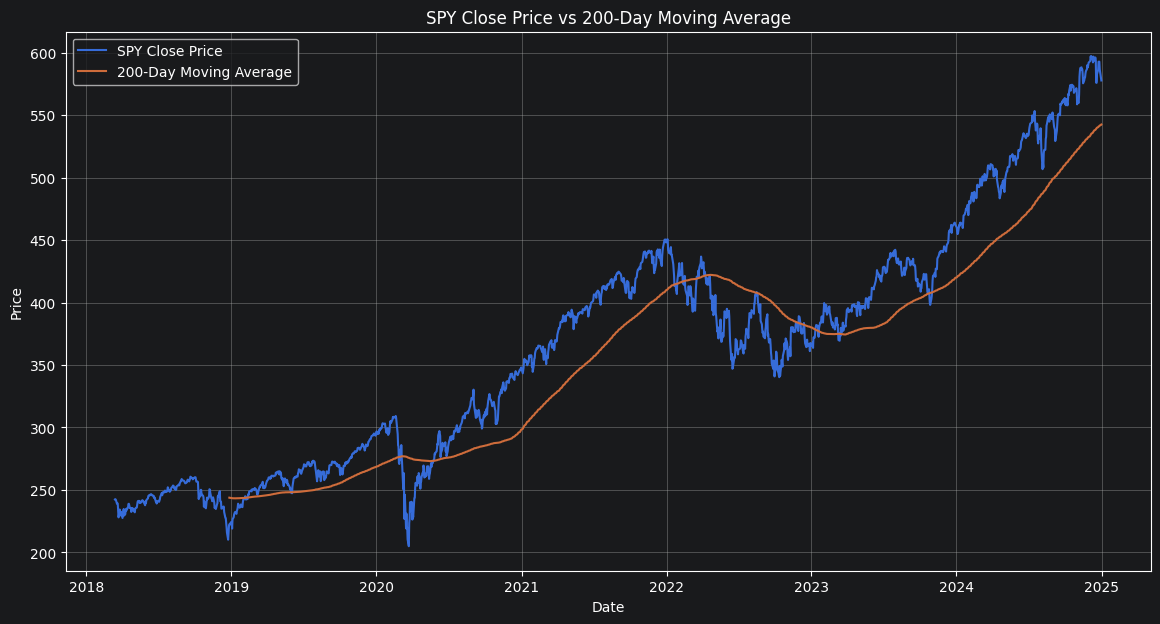

In [55]:
plt.figure(figsize=(14, 7))
plt.plot(data["Close"], label="SPY Close Price")
plt.plot(data["MA200"], label="200-Day Moving Average")
plt.title("SPY Close Price vs 200-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

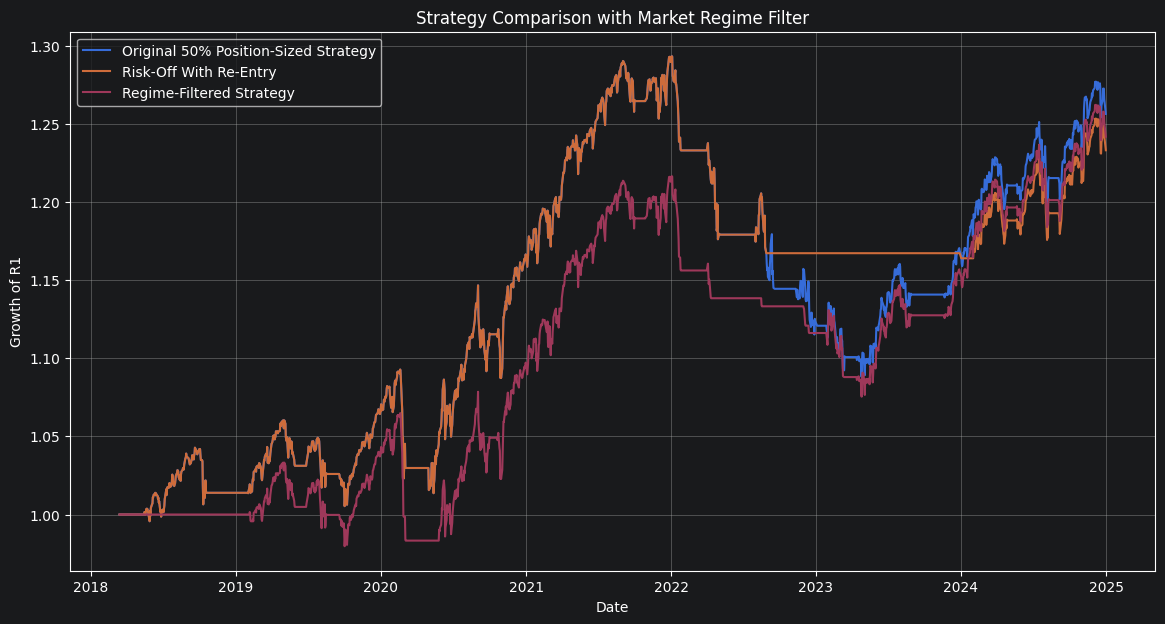

In [56]:
plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Growth_Position_Sized"], label="Original 50% Position-Sized Strategy")
plt.plot(data["Strategy_Growth_Risk_Managed_Reentry"], label="Risk-Off With Re-Entry")
plt.plot(data["Strategy_Growth_Regime_Filtered"], label="Regime-Filtered Strategy")
plt.title("Strategy Comparison with Market Regime Filter")
plt.xlabel("Date")
plt.ylabel("Growth of R1")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
# Total return
strategy_return_regime_filtered = data["Strategy_Growth_Regime_Filtered"].iloc[-1] - 1

# Volatility
strategy_volatility_regime_filtered = (
    data["Strategy_Return_Regime_Filtered_Position_Sized"].std() * np.sqrt(252)
)

# Sharpe ratio
strategy_sharpe_regime_filtered = (
    data["Strategy_Return_Regime_Filtered_Position_Sized"].mean() * 252
) / strategy_volatility_regime_filtered

print("Return - Original 50% Position Sized:", round(strategy_return_position_sized * 100, 2), "%")
print("Return - Risk-Off With Re-Entry:", round(strategy_return_reentry * 100, 2), "%")
print("Return - Regime-Filtered Strategy:", round(strategy_return_regime_filtered * 100, 2), "%")

print("Volatility - Original 50% Position Sized:", round(strategy_volatility_position_sized * 100, 2), "%")
print("Volatility - Risk-Off With Re-Entry:", round(strategy_volatility_reentry * 100, 2), "%")
print("Volatility - Regime-Filtered Strategy:", round(strategy_volatility_regime_filtered * 100, 2), "%")

print("Sharpe - Original 50% Position Sized:", round(strategy_sharpe_position_sized, 2))
print("Sharpe - Risk-Off With Re-Entry:", round(strategy_sharpe_reentry, 2))
print("Sharpe - Regime-Filtered Strategy:", round(strategy_sharpe_regime_filtered, 2))

Return - Original 50% Position Sized: 25.63 %
Return - Risk-Off With Re-Entry: 23.3 %
Return - Regime-Filtered Strategy: 24.17 %
Volatility - Original 50% Position Sized: 6.16 %
Volatility - Risk-Off With Re-Entry: 5.6 %
Volatility - Regime-Filtered Strategy: 5.34 %
Sharpe - Original 50% Position Sized: 0.58
Sharpe - Risk-Off With Re-Entry: 0.58
Sharpe - Regime-Filtered Strategy: 0.62


In [58]:
# Calculate drawdown for regime-filtered strategy
data["Strategy_Peak_Regime_Filtered"] = data["Strategy_Growth_Regime_Filtered"].cummax()

data["Strategy_Drawdown_Regime_Filtered"] = (
    data["Strategy_Growth_Regime_Filtered"] -
    data["Strategy_Peak_Regime_Filtered"]
) / data["Strategy_Peak_Regime_Filtered"]

strategy_max_drawdown_regime_filtered = data["Strategy_Drawdown_Regime_Filtered"].min()

print("Max Drawdown - Original 50% Position Sized:", round(strategy_max_drawdown_position_sized * 100, 2), "%")
print("Max Drawdown - Risk-Off With Re-Entry:", round(strategy_max_drawdown_reentry * 100, 2), "%")
print("Max Drawdown - Regime-Filtered Strategy:", round(strategy_max_drawdown_regime_filtered * 100, 2), "%")

Max Drawdown - Original 50% Position Sized: -15.86 %
Max Drawdown - Risk-Off With Re-Entry: -10.0 %
Max Drawdown - Regime-Filtered Strategy: -11.59 %


Final Value - Original 50% Position Sized: R 12562.68
Final Value - Risk-Off With Re-Entry: R 12330.19
Final Value - Regime-Filtered Strategy: R 12416.72


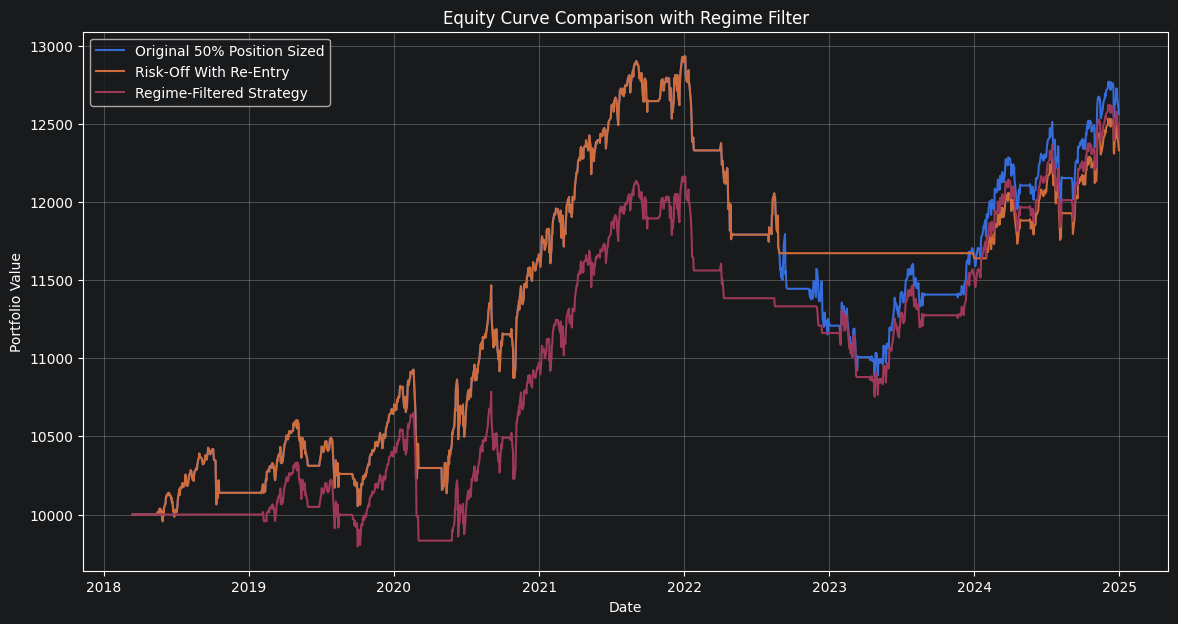

In [59]:
data["Strategy_Equity_Regime_Filtered"] = (
    initial_capital * data["Strategy_Growth_Regime_Filtered"]
)

print("Final Value - Original 50% Position Sized: R", round(data["Strategy_Equity_Position_Sized"].iloc[-1], 2))
print("Final Value - Risk-Off With Re-Entry: R", round(data["Strategy_Equity_Risk_Managed_Reentry"].iloc[-1], 2))
print("Final Value - Regime-Filtered Strategy: R", round(data["Strategy_Equity_Regime_Filtered"].iloc[-1], 2))

plt.figure(figsize=(14, 7))
plt.plot(data["Strategy_Equity_Position_Sized"], label="Original 50% Position Sized")
plt.plot(data["Strategy_Equity_Risk_Managed_Reentry"], label="Risk-Off With Re-Entry")
plt.plot(data["Strategy_Equity_Regime_Filtered"], label="Regime-Filtered Strategy")
plt.title("Equity Curve Comparison with Regime Filter")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# Create a performance summary table

summary_data = {
    "Strategy": [
        "Buy and Hold",
        "Moving Average Strategy",
        "Strategy After Costs",
        "50% Position-Sized Strategy",
        "Risk-Off With Re-Entry",
        "Regime-Filtered Strategy"
    ],

    "Total Return (%)": [
        buy_hold_return * 100,
        strategy_return * 100,
        strategy_return_after_cost * 100,
        strategy_return_position_sized * 100,
        strategy_return_reentry * 100,
        strategy_return_regime_filtered * 100
    ],

    "Volatility (%)": [
        buy_hold_volatility * 100,
        strategy_volatility * 100,
        strategy_volatility_after_cost * 100,
        strategy_volatility_position_sized * 100,
        strategy_volatility_reentry * 100,
        strategy_volatility_regime_filtered * 100
    ],

    "Sharpe Ratio": [
        buy_hold_sharpe,
        strategy_sharpe,
        strategy_sharpe_after_cost,
        strategy_sharpe_position_sized,
        strategy_sharpe_reentry,
        strategy_sharpe_regime_filtered
    ],

    "Max Drawdown (%)": [
        buy_hold_max_drawdown * 100,
        strategy_max_drawdown * 100,
        strategy_max_drawdown_after_cost * 100,
        strategy_max_drawdown_position_sized * 100,
        strategy_max_drawdown_reentry * 100,
        strategy_max_drawdown_regime_filtered * 100
    ],

    "Final Value (R)": [
        initial_capital * data["Buy_Hold_Growth"].iloc[-1],
        initial_capital * data["Strategy_Growth"].iloc[-1],
        initial_capital * data["Strategy_Growth_After_Cost"].iloc[-1],
        initial_capital * data["Strategy_Growth_Position_Sized"].iloc[-1],
        initial_capital * data["Strategy_Growth_Risk_Managed_Reentry"].iloc[-1],
        initial_capital * data["Strategy_Growth_Regime_Filtered"].iloc[-1]
    ]
}

summary_table = pd.DataFrame(summary_data)

summary_table

,Strategy,Total Return (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Final Value (R)
0,Buy and Hold,137.190402,19.470282,0.750885,-33.717260,23719.040210
1,Moving Average Strategy,58.306981,12.315107,0.610957,-28.887027,15830.698072
2,Strategy After Costs,53.773463,12.322614,0.575944,-29.596507,15377.346293
3,50% Position-Sized Strategy,25.626791,6.161307,0.575944,-15.864799,12562.679095
4,Risk-Off With Re-Entry,23.301907,5.598189,0.578838,-9.996659,12330.190735
5,Regime-Filtered Strategy,24.167220,5.340747,0.623724,-11.594125,12416.721952


In [61]:
# Round values for clean display
summary_table_rounded = summary_table.copy()

summary_table_rounded["Total Return (%)"] = summary_table_rounded["Total Return (%)"].round(2)
summary_table_rounded["Volatility (%)"] = summary_table_rounded["Volatility (%)"].round(2)
summary_table_rounded["Sharpe Ratio"] = summary_table_rounded["Sharpe Ratio"].round(2)
summary_table_rounded["Max Drawdown (%)"] = summary_table_rounded["Max Drawdown (%)"].round(2)
summary_table_rounded["Final Value (R)"] = summary_table_rounded["Final Value (R)"].round(2)

summary_table_rounded

,Strategy,Total Return (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Final Value (R)
0,Buy and Hold,137.19,19.47,0.75,-33.72,23719.04
1,Moving Average Strategy,58.31,12.32,0.61,-28.89,15830.70
2,Strategy After Costs,53.77,12.32,0.58,-29.60,15377.35
3,50% Position-Sized Strategy,25.63,6.16,0.58,-15.86,12562.68
4,Risk-Off With Re-Entry,23.30,5.60,0.58,-10.00,12330.19
5,Regime-Filtered Strategy,24.17,5.34,0.62,-11.59,12416.72


In [62]:
summary_table_rounded.sort_values(by="Sharpe Ratio", ascending=False)

,Strategy,Total Return (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Final Value (R)
0,Buy and Hold,137.19,19.47,0.75,-33.72,23719.04
5,Regime-Filtered Strategy,24.17,5.34,0.62,-11.59,12416.72
1,Moving Average Strategy,58.31,12.32,0.61,-28.89,15830.70
2,Strategy After Costs,53.77,12.32,0.58,-29.60,15377.35
3,50% Position-Sized Strategy,25.63,6.16,0.58,-15.86,12562.68
4,Risk-Off With Re-Entry,23.30,5.60,0.58,-10.00,12330.19


In [63]:
summary_table_rounded.sort_values(by="Max Drawdown (%)", ascending=False)

,Strategy,Total Return (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Final Value (R)
4,Risk-Off With Re-Entry,23.30,5.60,0.58,-10.00,12330.19
5,Regime-Filtered Strategy,24.17,5.34,0.62,-11.59,12416.72
3,50% Position-Sized Strategy,25.63,6.16,0.58,-15.86,12562.68
1,Moving Average Strategy,58.31,12.32,0.61,-28.89,15830.70
2,Strategy After Costs,53.77,12.32,0.58,-29.60,15377.35
0,Buy and Hold,137.19,19.47,0.75,-33.72,23719.04


In [64]:
summary_table_rounded.sort_values(by="Final Value (R)", ascending=False)

,Strategy,Total Return (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Final Value (R)
0,Buy and Hold,137.19,19.47,0.75,-33.72,23719.04
1,Moving Average Strategy,58.31,12.32,0.61,-28.89,15830.70
2,Strategy After Costs,53.77,12.32,0.58,-29.60,15377.35
3,50% Position-Sized Strategy,25.63,6.16,0.58,-15.86,12562.68
5,Regime-Filtered Strategy,24.17,5.34,0.62,-11.59,12416.72
4,Risk-Off With Re-Entry,23.30,5.60,0.58,-10.00,12330.19


In [65]:
summary_table_rounded.style.format({
    "Total Return (%)": "{:.2f}",
    "Volatility (%)": "{:.2f}",
    "Sharpe Ratio": "{:.2f}",
    "Max Drawdown (%)": "{:.2f}",
    "Final Value (R)": "R {:,.2f}"
})

,Strategy,Total Return (%),Volatility (%),Sharpe Ratio,Max Drawdown (%),Final Value (R)
0,Buy and Hold,137.19,19.47,0.75,-33.72,"R 23,719.04"
1,Moving Average Strategy,58.31,12.32,0.61,-28.89,"R 15,830.70"
2,Strategy After Costs,53.77,12.32,0.58,-29.60,"R 15,377.35"
3,50% Position-Sized Strategy,25.63,6.16,0.58,-15.86,"R 12,562.68"
4,Risk-Off With Re-Entry,23.30,5.60,0.58,-10.00,"R 12,330.19"
5,Regime-Filtered Strategy,24.17,5.34,0.62,-11.59,"R 12,416.72"
